#### [연속영역분할 2: 레이블링 (Connected Component Labeling)]<hr>

- 원리 : 서로 연결된 흰색 영역마다 서로 다른 번호를 부여
- 조건 : 이진화 이미지 데이터 사용
- 라벨링 방식
  * 배경: 레이블 `0`
  * 첫 번째 객체: 레이블 `1`
  * 두 번째 객체: 레이블 `2`

In [1]:
## -------------------------------------
## 이미지 데이터 로딩 & 기본 정보
## -------------------------------------
import cv2
import os
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")

import importlib
import cv_utils

importlib.reload(cv_utils)




<module 'cv_utils' from 'C:\\KDT14\\7_CV\\cv_utils.py'>

- [1] 서로 떨어진 객체 3개 만들기

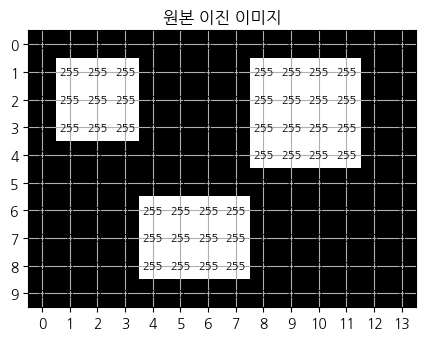

In [3]:
## ----------------------------------------
## 3개의 흰색 픽셀 영역 생성
## ----------------------------------------

imageNP = np.zeros((10, 14), dtype=np.uint8)

imageNP[1:4, 1:4] = 255
imageNP[1:5, 8:12] = 255
imageNP[6:9, 4:8] = 255

## 픽셀값과 시각화
cv_utils.printDistance(imageNP, imageNP, "원본 이진 이미지")

In [5]:
## => 라벨링 진행
##    라벨링 후 통계 정보까지 반환 받음
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    imageNP,
    connectivity=8
)

## => 정보 출력
print("배경을 포함한 전체 레이블 수:", num_labels)
print("실제 객체 수:", num_labels - 1)
print("\n레이블 행렬")
print(labels)

print("\n객체별 통계정보")
print(stats)

print("\n객체별 중심점")
print(centroids)


배경을 포함한 전체 레이블 수: 4
실제 객체 수: 3

레이블 행렬
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 1 1 0 0 0 0 2 2 2 2 0 0]
 [0 1 1 1 0 0 0 0 2 2 2 2 0 0]
 [0 1 1 1 0 0 0 0 2 2 2 2 0 0]
 [0 0 0 0 0 0 0 0 2 2 2 2 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 3 3 3 3 0 0 0 0 0 0]
 [0 0 0 0 3 3 3 3 0 0 0 0 0 0]
 [0 0 0 0 3 3 3 3 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

객체별 통계정보
[[  0   0  14  10 103]
 [  1   1   3   3   9]
 [  8   1   4   4  16]
 [  4   6   4   3  12]]

객체별 중심점
[[6.54368932 4.73786408]
 [2.         2.        ]
 [9.5        2.5       ]
 [5.5        7.        ]]


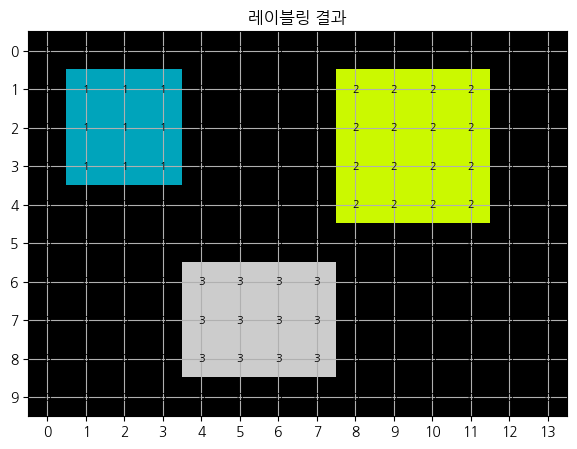

In [6]:
## => 라벨링 결과 시각화
##printDistance(labels, labels, "레이블링 결과", "nipy_spectral")
plt.figure(figsize=(8, 5))
plt.imshow(labels, cmap="nipy_spectral")

for y in range(labels.shape[0]):
    for x in range(labels.shape[1]):
        plt.text(x, y, str(labels[y, x]), ha="center", va="center", fontsize=8)

plt.title("레이블링 결과")
plt.xticks(range(labels.shape[1]))
plt.yticks(range(labels.shape[0]))
plt.grid()
plt.show()

In [7]:
## => 라벨링 객체별 정보 출력 --> 0 배경 제외
for label in range(1, num_labels):
    ## 통계정보 추출
    x      = stats[label, cv2.CC_STAT_LEFT]
    y      = stats[label, cv2.CC_STAT_TOP]
    width  = stats[label, cv2.CC_STAT_WIDTH]
    height = stats[label, cv2.CC_STAT_HEIGHT]
    area   = stats[label, cv2.CC_STAT_AREA]

    ## 중심 정보 추출
    center_x, center_y = centroids[label]

    ## 정보 출력
    print(f"객체 {label}")
    print(f"  왼쪽 위 위치: ({x}, {y})")
    print(f"  너비 x 높이: {width} x {height}")
    print(f"  면적: {area}")
    print(f"  중심점: ({center_x:.2f}, {center_y:.2f})")
    print()

객체 1
  왼쪽 위 위치: (1, 1)
  너비 x 높이: 3 x 3
  면적: 9
  중심점: (2.00, 2.00)

객체 2
  왼쪽 위 위치: (8, 1)
  너비 x 높이: 4 x 4
  면적: 16
  중심점: (9.50, 2.50)

객체 3
  왼쪽 위 위치: (4, 6)
  너비 x 높이: 4 x 3
  면적: 12
  중심점: (5.50, 7.00)



## 핵심 정리

레이블링은 서로 연결된 객체를 구별하고 개수를 셀 때 사용합니다.

활용 예:
- 객체 개수 세기
- 가장 큰 객체 선택
- 작은 노이즈 제거
- 객체의 중심점과 면적 계산